# 📈 Mean-Reversion Backtesting Framework
### Testing simple trading rules across different asset types

This notebook backtests **3 mean-reversion strategies** against buy-and-hold  
across multiple tickers representing different risk profiles.

| Strategy | Logic |
|---|---|
| **Buy & Hold** | Benchmark — buy once and hold |
| **Red Days** | Buy after N consecutive down days, hold for X days |
| **Drop / Rise** | Buy on a single-day drop ≥ X%, sell on rise ≥ Y% from entry |
| **Z-Score** | Buy when price is statistically cheap (low Z), sell when it normalizes |

---


In [1]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown, HTML
import yfinance as yf

warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)

plt.rcParams.update({
    "figure.facecolor":  "#f7f7f5",
    "axes.facecolor":    "#ffffff",
    "axes.edgecolor":    "#cccccc",
    "axes.labelcolor":   "#333333",
    "xtick.color":       "#555555",
    "ytick.color":       "#555555",
    "text.color":        "#222222",
    "grid.color":        "#e5e5e5",
    "grid.linewidth":    0.8,
    "legend.facecolor":  "#ffffff",
    "legend.edgecolor":  "#dddddd",
    "font.family":       "sans-serif",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
})

PALETTE = ["#2563eb", "#16a34a", "#d97706", "#7c3aed"]   # blue, green, amber, purple
print("\u2705  Imports ready.")


✅  Imports ready.


In [2]:
# ── Run configuration ─────────────────────────────────────────────────────────
run_id          = input("Run name (e.g. baseline_test_1): ").strip()
tickers         = [x.strip().upper() for x in input("Tickers, comma-separated (e.g. SPY,AAPL): ").split(",") if x.strip()]
start_date      = input("Start date (YYYY-MM-DD): ").strip()
end_date        = input("End date (YYYY-MM-DD), or press Enter for today: ").strip() or None
starting_capital = float(input("Starting capital (e.g. 1000): "))

# ── Strategy 1: Red Days ───────────────────────────────────────────────────────
red_days_needed = int(input("\nStrategy 1 — consecutive red days needed: "))
hold_days       = int(input("Strategy 1 — days to hold after signal: "))

# ── Strategy 2: Drop / Rise ───────────────────────────────────────────────────
buy_drop_pct  = float(input("\nStrategy 2 — buy when stock falls ≥ X% in one day: ")) / 100
sell_jump_pct = float(input("Strategy 2 — sell when price rises Y% from entry: "))  / 100

# ── Strategy 3: Z-Score ────────────────────────────────────────────────────────
z_window          = int(input("\nStrategy 3 — Z-score rolling window (days): "))
z_entry_threshold = float(input("Strategy 3 — buy when Z-score ≤: "))
z_exit_threshold  = float(input("Strategy 3 — sell when Z-score ≥: "))

# ── Transaction cost ──────────────────────────────────────────────────────────
tx_cost = float(input("\nTransaction cost per trade, as % (e.g. 0.1 for 0.1%): ")) / 100

os.makedirs("charts", exist_ok=True)
print(f"\n✅  Config saved — run ID: '{run_id}' | {len(tickers)} tickers | tx cost: {tx_cost:.2%}")


Run name (e.g. baseline_test_1):  Test
Tickers, comma-separated (e.g. SPY,AAPL):  Spy, msft, googl, nvda, hgraf
Start date (YYYY-MM-DD):  2020-01-01
End date (YYYY-MM-DD), or press Enter for today:  2026-04-08
Starting capital (e.g. 1000):  1000

Strategy 1 — consecutive red days needed:  2
Strategy 1 — days to hold after signal:  5

Strategy 2 — buy when stock falls ≥ X% in one day:  2
Strategy 2 — sell when price rises Y% from entry:  3

Strategy 3 — Z-score rolling window (days):  20
Strategy 3 — buy when Z-score ≤:  -1.5
Strategy 3 — sell when Z-score ≥:  0.5

Transaction cost per trade, as % (e.g. 0.1 for 0.1%):  .1



✅  Config saved — run ID: 'Test' | 5 tickers | tx cost: 0.10%


In [3]:
def max_drawdown(curve):
    peak = curve.cummax()
    return float(((curve - peak) / peak).min())

def sharpe_ratio(daily_returns):
    mu  = daily_returns.mean()
    sig = daily_returns.std()
    return float(mu / sig * np.sqrt(252)) if sig > 0 else float("nan")

def get_close(ticker, start, end=None):
    raw = yf.download(ticker, start=start, end=end_date, auto_adjust=True, progress=False)
    if raw.empty:
        return None
    cols = raw.columns
    if isinstance(cols, pd.MultiIndex):
        lvl = 0 if "Close" in cols.get_level_values(0) else 1
        close = raw.xs("Close", axis=1, level=lvl)
        if isinstance(close, pd.DataFrame):
            if close.shape[1] != 1:
                return None
            close = close.iloc[:, 0]
    else:
        if "Close" not in cols:
            return None
        close = raw["Close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
    close = pd.to_numeric(close, errors="coerce").dropna()
    close.index.name = None
    return close

def style_summary(df):
    numeric_cols = df.select_dtypes(include="number").columns.tolist()

    fmt = {}
    for col in df.columns:
        if "Value" in col or "P/L" in col or "Profit" in col or "Capital" in col:
            fmt[col] = "${:,.2f}"
        elif "Return" in col or "Volatility" in col or "Drawdown" in col or "Win" in col or "Rate" in col:
            fmt[col] = "{:.2%}"
        elif "Sharpe" in col:
            fmt[col] = "{:.2f}"
        elif "Avg Daily" in col:
            fmt[col] = "{:.1%}"

    def _color_value(val):
        if not isinstance(val, (int, float)) or (isinstance(val, float) and val != val):
            return ""
        return "color: #16a34a; font-weight: 600" if val > 0 else "color: #dc2626; font-weight: 600"

    style = (
        df.style
        .format(fmt, na_rep="\u2014")
        .set_table_styles([
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("font-family", "sans-serif"),
                ("font-size", "12px"),
                ("width", "100%"),
            ]},
            {"selector": "thead th", "props": [
                ("background-color", "#f0f4ff"),
                ("color", "#1e40af"),
                ("font-size", "11px"),
                ("font-weight", "700"),
                ("border-bottom", "2px solid #c7d2fe"),
                ("padding", "9px 14px"),
                ("text-align", "center"),
                ("white-space", "nowrap"),
            ]},
            {"selector": "tbody td", "props": [
                ("background-color", "#ffffff"),
                ("color", "#222222"),
                ("font-size", "11px"),
                ("border-bottom", "1px solid #f0f0f0"),
                ("padding", "7px 14px"),
                ("text-align", "center"),
            ]},
            {"selector": "tbody tr:nth-child(even) td", "props": [
                ("background-color", "#fafafa"),
            ]},
            {"selector": "tbody tr:hover td", "props": [
                ("background-color", "#eff6ff"),
            ]},
        ])
        .hide(axis="index")
    )
    for col in ["Total Return", "P/L", "Profit / Loss", "Sharpe"]:
        matching = [c for c in df.columns if col in c]
        for c in matching:
            if c in numeric_cols:
                style = style.applymap(_color_value, subset=[c])
    return style

print("\u2705  Helper functions defined.")


✅  Helper functions defined.


---
## 📊 SPY

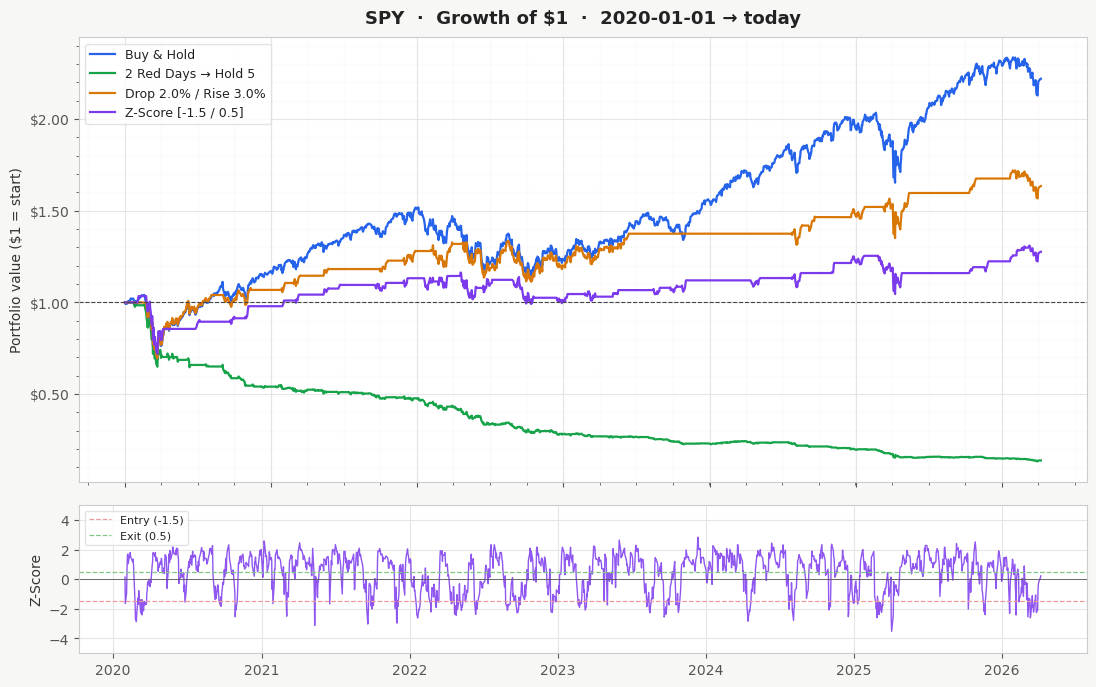

Strategy,Final Value,P/L,Total Return,Sharpe,Max Drawdown,Avg Daily Return,Volatility,Signals,Trades,Win Rate,Beat B&H?
Buy & Hold,"$2,220.43","$1,220.43",122.04%,0.73,-33.72%,0.06%,1.29%,—,—,—,—
2 Red Days → Hold 5,$138.15,$-861.85,-86.19%,-1.74,-86.67%,-0.12%,1.09%,311.000000,—,—,❌
Drop 2.0% / Rise 3.0%,"$1,634.89",$634.89,63.49%,0.52,-30.44%,0.04%,1.16%,—,15.000000,93.33%,❌
Z-Score [-1.5 / 0.5],"$1,276.72",$276.72,27.67%,0.32,-30.44%,0.02%,1.03%,173.000000,33.000000,81.82%,❌


---
## 📊 MSFT

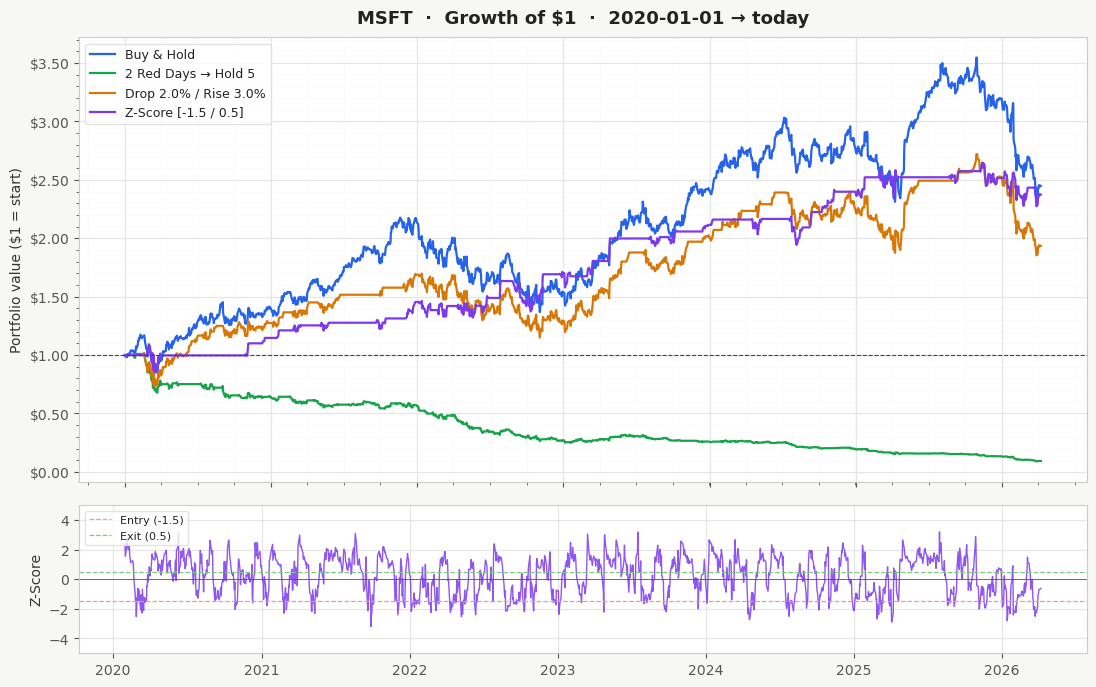

Strategy,Final Value,P/L,Total Return,Sharpe,Max Drawdown,Avg Daily Return,Volatility,Signals,Trades,Win Rate,Beat B&H?
Buy & Hold,"$2,446.73","$1,446.73",144.67%,0.63,-37.15%,0.07%,1.87%,—,—,—,—
2 Red Days → Hold 5,$93.56,$-906.44,-90.64%,-1.42,-91.07%,-0.14%,1.55%,340.000000,—,—,❌
Drop 2.0% / Rise 3.0%,"$1,933.86",$933.86,93.39%,0.52,-32.24%,0.06%,1.74%,—,26.000000,96.15%,❌
Z-Score [-1.5 / 0.5],"$2,372.10","$1,372.10",137.21%,0.77,-21.63%,0.06%,1.32%,179.000000,37.000000,81.08%,❌


---
## 📊 GOOGL

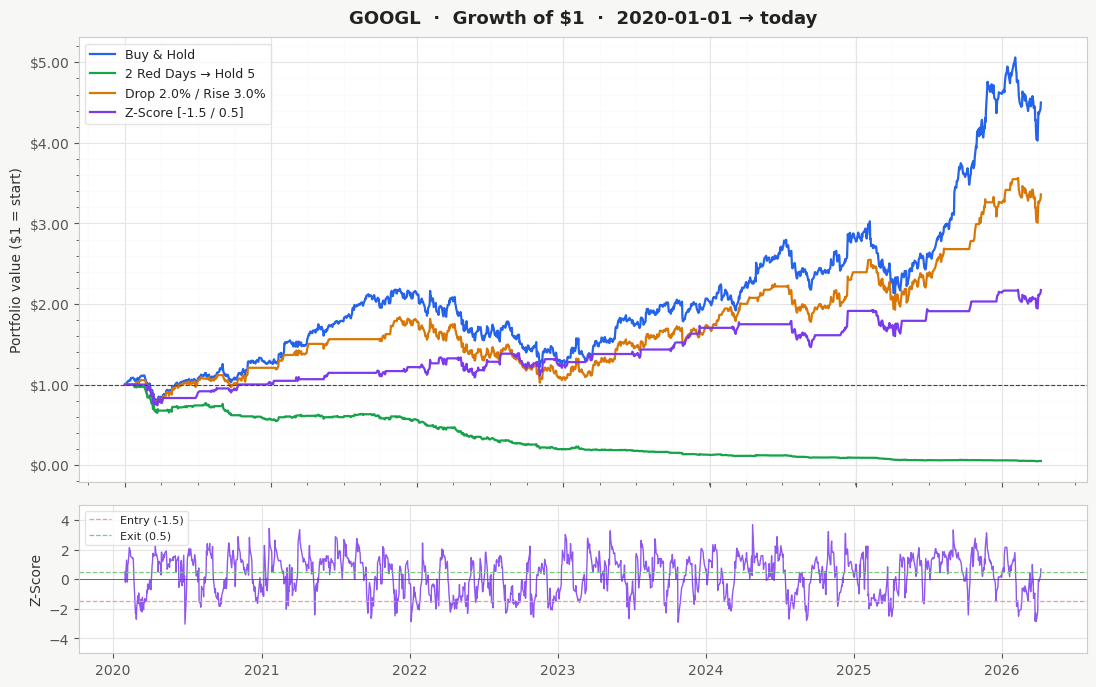

Strategy,Final Value,P/L,Total Return,Sharpe,Max Drawdown,Avg Daily Return,Volatility,Signals,Trades,Win Rate,Beat B&H?
Buy & Hold,"$4,500.46","$3,500.46",350.05%,0.91,-44.32%,0.12%,2.03%,—,—,—,—
2 Red Days → Hold 5,$51.07,$-948.93,-94.89%,-1.73,-95.30%,-0.18%,1.61%,324.000000,—,—,❌
Drop 2.0% / Rise 3.0%,"$3,360.81","$2,360.81",236.08%,0.81,-44.32%,0.09%,1.84%,—,31.000000,96.77%,❌
Z-Score [-1.5 / 0.5],"$2,173.19","$1,173.19",117.32%,0.69,-25.76%,0.06%,1.35%,172.000000,33.000000,78.79%,❌


---
## 📊 NVDA

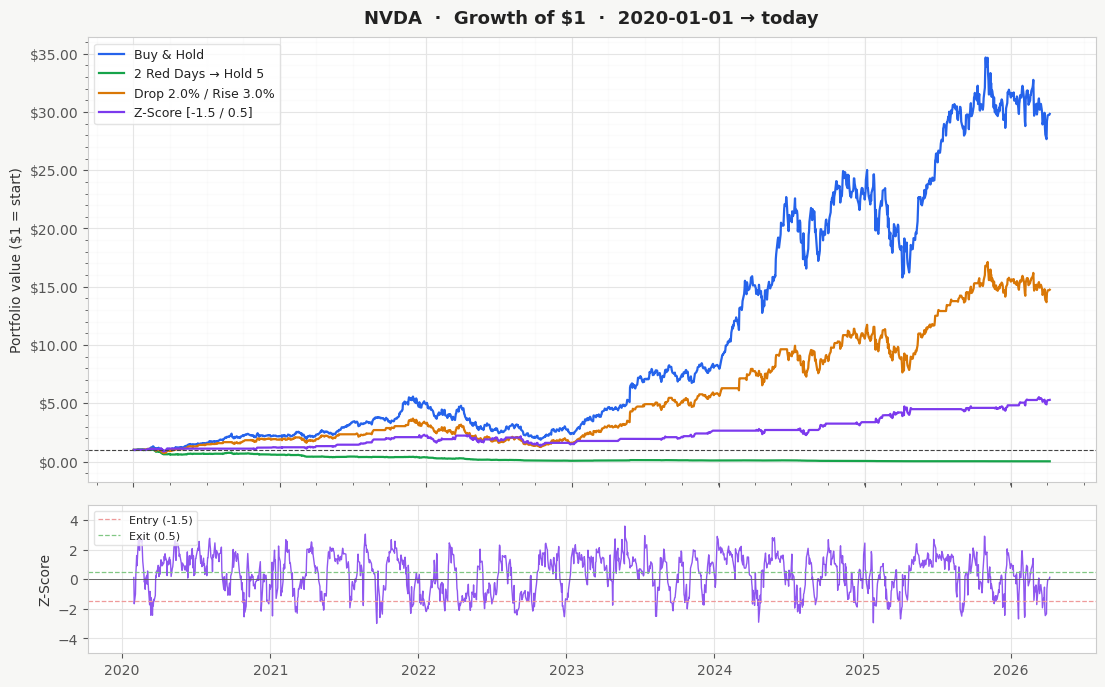

Strategy,Final Value,P/L,Total Return,Sharpe,Max Drawdown,Avg Daily Return,Volatility,Signals,Trades,Win Rate,Beat B&H?
Buy & Hold,"$29,828.73","$28,828.73",2882.87%,1.30,-66.34%,0.27%,3.31%,—,—,—,—
2 Red Days → Hold 5,$21.82,$-978.18,-97.82%,-1.23,-98.06%,-0.21%,2.68%,321.000000,—,—,❌
Drop 2.0% / Rise 3.0%,"$14,743.19","$13,743.19",1374.32%,1.12,-66.34%,0.22%,3.11%,—,54.000000,98.15%,❌
Z-Score [-1.5 / 0.5],"$5,290.78","$4,290.78",429.08%,0.96,-40.96%,0.13%,2.11%,150.000000,34.000000,85.29%,❌


---
## 📊 HGRAF

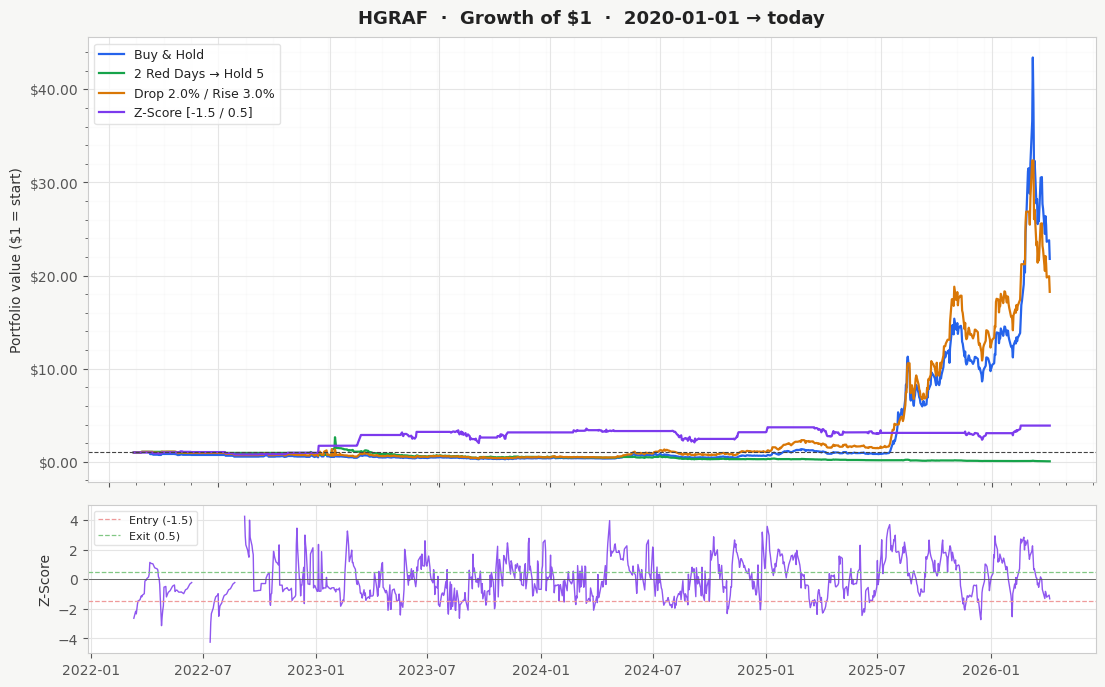

Strategy,Final Value,P/L,Total Return,Sharpe,Max Drawdown,Avg Daily Return,Volatility,Signals,Trades,Win Rate,Beat B&H?
Buy & Hold,"$21,789.47","$20,789.47",2078.95%,1.16,-74.00%,0.65%,8.90%,—,—,—,—
2 Red Days → Hold 5,$52.38,$-947.62,-94.76%,-0.27,-98.01%,-0.11%,6.45%,190.000000,—,—,❌
Drop 2.0% / Rise 3.0%,"$18,251.82","$17,251.82",1725.18%,1.12,-74.00%,0.60%,8.50%,—,32.000000,96.88%,❌
Z-Score [-1.5 / 0.5],"$3,889.33","$2,889.33",288.93%,0.79,-41.57%,0.20%,3.98%,96.000000,19.000000,68.42%,❌



✅  All tickers processed.


In [4]:
summary_rows      = []
trade_log_2_rows  = []
trade_log_3_rows  = []

strat1_label = f"{red_days_needed} Red Days → Hold {hold_days}"
strat2_label = f"Drop {buy_drop_pct:.1%} / Rise {sell_jump_pct:.1%}"
strat3_label = f"Z-Score [{z_entry_threshold} / {z_exit_threshold}]"

for ticker in tickers:
    display(Markdown(f"---\n## 📊 {ticker}"))

    close = get_close(ticker, start_date, end_date)
    if close is None or close.empty:
        print(f"⚠️  No usable data for {ticker} — skipping.")
        continue

    df = pd.DataFrame({"Close": close})
    df["return"]   = df["Close"].pct_change().fillna(0.0)
    df["c_market"] = (1 + df["return"]).cumprod()
    df["red_day"]  = df["return"] < 0

    # ── Strategy 1: Red Days (vectorised hold window) ──────────────────────────
    consec = df["red_day"].rolling(red_days_needed).sum() == red_days_needed
    raw_sig = consec.shift(1).fillna(False)
    # extend signal forward for hold_days using a reversed rolling max
    df["position_1"] = (
        raw_sig[::-1]
        .rolling(hold_days, min_periods=1)
        .max()
        [::-1]
        .astype(int)
    )
    df["red_signal"]      = raw_sig
    df["strat1_ret"]      = df["position_1"].shift(1).fillna(0) * df["return"]
    df["strat1_ret"]     -= tx_cost * raw_sig.shift(1).fillna(False).astype(float)
    df["c_strategy1"]     = (1 + df["strat1_ret"]).cumprod()

    # ── Strategy 2: Drop / Rise (state-machine) ────────────────────────────────
    df["position_2"] = 0
    trade_log_2, in2, ep2, ed2 = [], False, None, None

    for i in range(len(df)):
        price = float(df["Close"].iloc[i])
        if not in2:
            if df["return"].iloc[i] <= -buy_drop_pct:
                in2, ep2, ed2 = True, price * (1 + tx_cost), df.index[i]
                df.iloc[i, df.columns.get_loc("position_2")] = 1
        else:
            df.iloc[i, df.columns.get_loc("position_2")] = 1
            if price >= ep2 * (1 + sell_jump_pct):
                exit_p = price * (1 - tx_cost)
                trade_log_2.append({
                    "Run ID": run_id, "Ticker": ticker, "Strategy": strat2_label,
                    "Start Date": start_date, "Buy Drop %": buy_drop_pct, "Sell Jump %": sell_jump_pct,
                    "Entry Date": ed2, "Exit Date": df.index[i],
                    "Entry Price": ep2, "Exit Price": exit_p,
                    "Trade Return": (exit_p - ep2) / ep2,
                })
                in2, ep2, ed2 = False, None, None

    if in2:
        exit_p = float(df["Close"].iloc[-1]) * (1 - tx_cost)
        trade_log_2.append({
            "Run ID": run_id, "Ticker": ticker, "Strategy": strat2_label,
            "Start Date": start_date, "Buy Drop %": buy_drop_pct, "Sell Jump %": sell_jump_pct,
            "Entry Date": ed2, "Exit Date": df.index[-1],
            "Entry Price": ep2, "Exit Price": exit_p,
            "Trade Return": (exit_p - ep2) / ep2,
        })

    df["strat2_ret"]  = df["position_2"].shift(1).fillna(0) * df["return"]
    df["c_strategy2"] = (1 + df["strat2_ret"]).cumprod()

    # ── Strategy 3: Z-Score (state-machine) ────────────────────────────────────
    df["z_mean"]  = df["Close"].rolling(z_window).mean()
    df["z_std"]   = df["Close"].rolling(z_window).std()
    df["z_score"] = np.where(df["z_std"] > 0, (df["Close"] - df["z_mean"]) / df["z_std"], np.nan)
    df["z_buy_signal"] = df["z_score"] <= z_entry_threshold
    df["position_3"] = 0
    trade_log_3, in3, ep3, ed3 = [], False, None, None

    for i in range(len(df)):
        price = float(df["Close"].iloc[i])
        z = df["z_score"].iloc[i]
        if not in3:
            if pd.notna(z) and z <= z_entry_threshold:
                in3, ep3, ed3 = True, price * (1 + tx_cost), df.index[i]
                df.iloc[i, df.columns.get_loc("position_3")] = 1
        else:
            df.iloc[i, df.columns.get_loc("position_3")] = 1
            if pd.notna(z) and z >= z_exit_threshold:
                exit_p = price * (1 - tx_cost)
                trade_log_3.append({
                    "Run ID": run_id, "Ticker": ticker, "Strategy": strat3_label,
                    "Start Date": start_date, "Z Window": z_window,
                    "Z Entry": z_entry_threshold, "Z Exit": z_exit_threshold,
                    "Entry Date": ed3, "Exit Date": df.index[i],
                    "Entry Price": ep3, "Exit Price": exit_p,
                    "Trade Return": (exit_p - ep3) / ep3,
                })
                in3, ep3, ed3 = False, None, None

    if in3:
        exit_p = float(df["Close"].iloc[-1]) * (1 - tx_cost)
        trade_log_3.append({
            "Run ID": run_id, "Ticker": ticker, "Strategy": strat3_label,
            "Start Date": start_date, "Z Window": z_window,
            "Z Entry": z_entry_threshold, "Z Exit": z_exit_threshold,
            "Entry Date": ed3, "Exit Date": df.index[-1],
            "Entry Price": ep3, "Exit Price": exit_p,
            "Trade Return": (exit_p - ep3) / ep3,
        })

    df["strat3_ret"]  = df["position_3"].shift(1).fillna(0) * df["return"]
    df["c_strategy3"] = (1 + df["strat3_ret"]).cumprod()

    # ── Per-ticker chart ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                             gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})
    ax, ax2 = axes

    curves = {
        "Buy & Hold":  df["c_market"],
        strat1_label:  df["c_strategy1"],
        strat2_label:  df["c_strategy2"],
        strat3_label:  df["c_strategy3"],
    }
    for (label, curve), color in zip(curves.items(), PALETTE):
        ax.plot(df.index, curve, label=label, color=color, linewidth=1.6)

    ax.axhline(1, color="#444", linewidth=0.8, linestyle="--")
    ax.set_title(f"{ticker}  ·  Growth of $1  ·  {start_date} → today", pad=10)
    ax.set_ylabel("Portfolio value ($1 = start)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.2f"))
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, which="major"); ax.grid(True, which="minor", alpha=0.15)
    ax.minorticks_on()
    ax.set_xticklabels([])

    # Z-score sub-plot
    ax2.plot(df.index, df["z_score"], color=PALETTE[3], linewidth=1, alpha=0.85)
    ax2.axhline(z_entry_threshold, color="#ef9a9a", linewidth=0.9, linestyle="--", label=f"Entry ({z_entry_threshold})")
    ax2.axhline(z_exit_threshold,  color="#81c784", linewidth=0.9, linestyle="--", label=f"Exit ({z_exit_threshold})")
    ax2.axhline(0, color="#555", linewidth=0.6)
    ax2.set_ylabel("Z-Score")
    ax2.set_ylim(-5, 5)
    ax2.legend(loc="upper left", fontsize=8)
    ax2.grid(True, which="major")

    plt.savefig(f"charts/{run_id}_{ticker}_comparison.png", dpi=150, bbox_inches="tight",
                facecolor="#f7f7f5")
    plt.show()

    # ── Per-ticker metrics table ───────────────────────────────────────────────
    tl2 = pd.DataFrame(trade_log_2)
    tl3 = pd.DataFrame(trade_log_3)

    def _metrics(ret_series, c_series, trades_df=None, sig_col=None):
        fv  = starting_capital * float(c_series.iloc[-1])
        pl  = fv - starting_capital
        tr  = float(c_series.iloc[-1]) - 1
        adr = float(ret_series.mean())
        vol = float(ret_series.std())
        mdd = max_drawdown(c_series)
        sr  = sharpe_ratio(ret_series)
        n_trades   = len(trades_df) if trades_df is not None and not trades_df.empty else np.nan
        win_r      = float((trades_df["Trade Return"] > 0).mean()) if trades_df is not None and not trades_df.empty else np.nan
        sig_count  = int(sig_col.sum()) if sig_col is not None else np.nan
        return fv, pl, tr, adr, vol, mdd, sr, sig_count, n_trades, win_r

    mkt_fv, mkt_pl, mkt_tr, *_ = _metrics(df["return"], df["c_market"])
    s1 = _metrics(df["strat1_ret"], df["c_strategy1"], sig_col=df["red_signal"])
    s2 = _metrics(df["strat2_ret"], df["c_strategy2"], trades_df=tl2)
    s3 = _metrics(df["strat3_ret"], df["c_strategy3"], trades_df=tl3, sig_col=df["z_buy_signal"])

    labels = ["Buy & Hold", strat1_label, strat2_label, strat3_label]
    sets   = [
        (df["return"],    df["c_market"],    None, None),
        (df["strat1_ret"], df["c_strategy1"], None, df["red_signal"]),
        (df["strat2_ret"], df["c_strategy2"], tl2,  None),
        (df["strat3_ret"], df["c_strategy3"], tl3,  df["z_buy_signal"]),
    ]

    rows = []
    for lbl, (ret, cv, tdf, sig) in zip(labels, sets):
        fv, pl, tr, adr, vol, mdd, sr, nsig, ntrades, wr = _metrics(ret, cv, tdf, sig)
        beat = "✅" if tr > mkt_tr and lbl != "Buy & Hold" else ("—" if lbl == "Buy & Hold" else "❌")
        rows.append({
            "Strategy": lbl,
            "Final Value": fv,
            "P/L": pl,
            "Total Return": tr,
            "Sharpe": sr,
            "Max Drawdown": mdd,
            "Avg Daily Return": adr,
            "Volatility": vol,
            "Signals": nsig,
            "Trades": ntrades,
            "Win Rate": wr,
            "Beat B&H?": beat,
        })
        summary_rows.append({
                "Run ID": run_id, "Ticker": ticker, "Strategy": lbl,
                "Start Date": start_date, "Starting Capital": starting_capital,
                "Final Portfolio Value": fv, "Profit / Loss": pl,
                "Total Return": tr, "Sharpe Ratio": sr,
                "Avg Daily Return": adr, "Daily Volatility": vol,
                "Max Drawdown": mdd, "Signal Count": nsig,
                "Completed Trades": ntrades, "Win Rate": wr, "Beat B&H": beat,
                "Red Days": red_days_needed, "Hold Days": hold_days,
                "Buy Drop %": buy_drop_pct, "Sell Jump %": sell_jump_pct,
                "Z Window": z_window, "Z Entry": z_entry_threshold, "Z Exit": z_exit_threshold,
                "Tx Cost %": tx_cost,
            })

    per_ticker_df = pd.DataFrame(rows)
    display(style_summary(per_ticker_df))

    if not tl2.empty:
        trade_log_2_rows.extend(tl2.to_dict("records"))
    if not tl3.empty:
        trade_log_3_rows.extend(tl3.to_dict("records"))

print("\n✅  All tickers processed.")


---
# 🗂️ Master Summary — This Run

### All Strategies

Run ID,Ticker,Strategy,Start Date,Starting Capital,Final Portfolio Value,Profit / Loss,Total Return,Sharpe Ratio,Avg Daily Return,Daily Volatility,Max Drawdown,Signal Count,Completed Trades,Win Rate,Beat B&H,Red Days,Hold Days,Buy Drop %,Sell Jump %,Z Window,Z Entry,Z Exit,Tx Cost %
Test,SPY,Buy & Hold,2020-01-01,"$1,000.00","$2,220.43","$1,220.43",122.04%,0.73,0.06%,1.29%,-33.72%,—,—,—,—,2,5,0.020000,0.030000,2000.00%,-1.500000,0.500000,0.001000
Test,SPY,2 Red Days → Hold 5,2020-01-01,"$1,000.00",$138.15,$-861.85,-86.19%,-1.74,-0.12%,1.09%,-86.67%,311.000000,—,—,❌,2,5,0.020000,0.030000,2000.00%,-1.500000,0.500000,0.001000
Test,SPY,Drop 2.0% / Rise 3.0%,2020-01-01,"$1,000.00","$1,634.89",$634.89,63.49%,0.52,0.04%,1.16%,-30.44%,—,15.000000,93.33%,❌,2,5,0.020000,0.030000,2000.00%,-1.500000,0.500000,0.001000
Test,SPY,Z-Score [-1.5 / 0.5],2020-01-01,"$1,000.00","$1,276.72",$276.72,27.67%,0.32,0.02%,1.03%,-30.44%,173.000000,33.000000,81.82%,❌,2,5,0.020000,0.030000,2000.00%,-1.500000,0.500000,0.001000
Test,MSFT,Buy & Hold,2020-01-01,"$1,000.00","$2,446.73","$1,446.73",144.67%,0.63,0.07%,1.87%,-37.15%,—,—,—,—,2,5,0.020000,0.030000,2000.00%,-1.500000,0.500000,0.001000
Test,MSFT,2 Red Days → Hold 5,2020-01-01,"$1,000.00",$93.56,$-906.44,-90.64%,-1.42,-0.14%,1.55%,-91.07%,340.000000,—,—,❌,2,5,0.020000,0.030000,2000.00%,-1.500000,0.500000,0.001000
Test,MSFT,Drop 2.0% / Rise 3.0%,2020-01-01,"$1,000.00","$1,933.86",$933.86,93.39%,0.52,0.06%,1.74%,-32.24%,—,26.000000,96.15%,❌,2,5,0.020000,0.030000,2000.00%,-1.500000,0.500000,0.001000
Test,MSFT,Z-Score [-1.5 / 0.5],2020-01-01,"$1,000.00","$2,372.10","$1,372.10",137.21%,0.77,0.06%,1.32%,-21.63%,179.000000,37.000000,81.08%,❌,2,5,0.020000,0.030000,2000.00%,-1.500000,0.500000,0.001000
Test,GOOGL,Buy & Hold,2020-01-01,"$1,000.00","$4,500.46","$3,500.46",350.05%,0.91,0.12%,2.03%,-44.32%,—,—,—,—,2,5,0.020000,0.030000,2000.00%,-1.500000,0.500000,0.001000
Test,GOOGL,2 Red Days → Hold 5,2020-01-01,"$1,000.00",$51.07,$-948.93,-94.89%,-1.73,-0.18%,1.61%,-95.30%,324.000000,—,—,❌,2,5,0.020000,0.030000,2000.00%,-1.500000,0.500000,0.001000


### 🔥 Total Return — Ticker × Strategy

> Buy & Hold is included as the baseline. Green = beat it, Red = didn't.

Strategy,Buy & Hold,2 Red Days → Hold 5,Drop 2.0% / Rise 3.0%,Z-Score [-1.5 / 0.5]
Ticker,,,,
GOOGL,350.0%,-94.9%,236.1%,117.3%
HGRAF,2078.9%,-94.8%,1725.2%,288.9%
MSFT,144.7%,-90.6%,93.4%,137.2%
NVDA,2882.9%,-97.8%,1374.3%,429.1%
SPY,122.0%,-86.2%,63.5%,27.7%


### ⚡ Sharpe Ratio — Ticker × Strategy

> **What is Sharpe?** Return per unit of risk. Above 1.0 is decent, above 2.0 is strong. Buy & Hold is the baseline — anything to its right should beat it to be worth it.

Strategy,Buy & Hold,2 Red Days → Hold 5,Drop 2.0% / Rise 3.0%,Z-Score [-1.5 / 0.5]
Ticker,,,,
GOOGL,0.91,-1.73,0.81,0.69
HGRAF,1.16,-0.27,1.12,0.79
MSFT,0.63,-1.42,0.52,0.77
NVDA,1.30,-1.23,1.12,0.96
SPY,0.73,-1.74,0.52,0.32


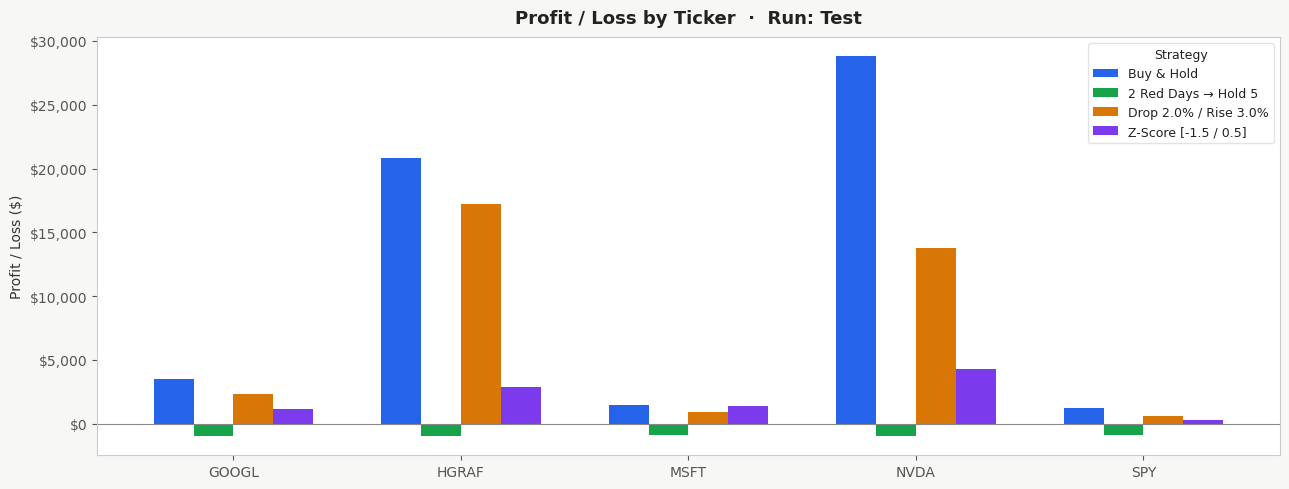


✅  Saved to:
   master_strategy_summary.csv
   master_strategy2_trade_log.csv
   master_strategy3_trade_log.csv
   charts/


In [5]:
display(Markdown("---\n# \U0001f5c2\ufe0f Master Summary \u2014 This Run"))

summary_df = pd.DataFrame(summary_rows)

def _append_csv(path, new_df):
    if os.path.exists(path) and not new_df.empty:
        pd.concat([pd.read_csv(path), new_df], ignore_index=True).to_csv(path, index=False)
    elif not new_df.empty:
        new_df.to_csv(path, index=False)

_append_csv("master_strategy_summary.csv",    summary_df)
_append_csv("master_strategy2_trade_log.csv", pd.DataFrame(trade_log_2_rows))
_append_csv("master_strategy3_trade_log.csv", pd.DataFrame(trade_log_3_rows))

display(Markdown("### All Strategies"))
display(style_summary(summary_df))

HEATMAP_STYLES = [
    {"selector": "table", "props": [
        ("border-collapse", "collapse"), ("font-family", "sans-serif"),
        ("font-size", "13px"), ("width", "100%"),
    ]},
    {"selector": "thead th", "props": [
        ("background-color", "#1e40af"), ("color", "#ffffff"),
        ("font-size", "12px"), ("font-weight", "700"),
        ("padding", "10px 16px"), ("text-align", "center"),
        ("white-space", "nowrap"),
    ]},
    {"selector": "tbody th", "props": [
        ("background-color", "#f0f4ff"), ("color", "#1e40af"),
        ("font-weight", "700"), ("padding", "9px 14px"),
        ("border-right", "2px solid #c7d2fe"),
    ]},
    {"selector": "tbody td", "props": [
        ("font-size", "13px"), ("font-weight", "600"),
        ("padding", "9px 16px"), ("text-align", "center"),
        ("color", "#111111"),
    ]},
]

# ── Total Return heatmap (includes Buy & Hold) ────────────────────────────────
display(Markdown("### \U0001f525 Total Return \u2014 Ticker \xd7 Strategy"))
display(Markdown("> Buy & Hold is included as the baseline. Green = beat it, Red = didn't."))
if not summary_df.empty:
    heat = summary_df.pivot(index="Ticker", columns="Strategy", values="Total Return")
    # reorder so Buy & Hold is first column
    cols = ["Buy & Hold"] + [c for c in heat.columns if c != "Buy & Hold"]
    heat = heat[cols]
    display(
        heat.style
        .format("{:.1%}", na_rep="\u2014")
        .background_gradient(cmap="RdYlGn", axis=None, vmin=-0.5, vmax=1.5)
        .set_properties(**{"color": "#111111", "font-weight": "600"})
        .set_table_styles(HEATMAP_STYLES)
    )

# ── Sharpe heatmap (includes Buy & Hold) ─────────────────────────────────────
display(Markdown("### \u26a1 Sharpe Ratio \u2014 Ticker \xd7 Strategy"))
display(Markdown("> **What is Sharpe?** Return per unit of risk. Above 1.0 is decent, above 2.0 is strong. Buy & Hold is the baseline — anything to its right should beat it to be worth it."))
if not summary_df.empty:
    sharpe_heat = summary_df.pivot(index="Ticker", columns="Strategy", values="Sharpe Ratio")
    cols = ["Buy & Hold"] + [c for c in sharpe_heat.columns if c != "Buy & Hold"]
    sharpe_heat = sharpe_heat[cols]
    display(
        sharpe_heat.style
        .format("{:.2f}", na_rep="\u2014")
        .background_gradient(cmap="RdYlGn", axis=None, vmin=-1, vmax=2)
        .set_properties(**{"color": "#111111", "font-weight": "600"})
        .set_table_styles(HEATMAP_STYLES)
    )

# ── Bar chart ──────────────────────────────────────────────────────────────────
if not summary_df.empty:
    pivot = summary_df.pivot(index="Ticker", columns="Strategy", values="Profit / Loss")
    cols = ["Buy & Hold"] + [c for c in pivot.columns if c != "Buy & Hold"]
    pivot = pivot[cols]
    fig, ax = plt.subplots(figsize=(13, 5))
    pivot.plot(kind="bar", ax=ax, color=PALETTE, width=0.7, edgecolor="none")
    ax.axhline(0, color="#888", linewidth=0.8)
    ax.set_title(f"Profit / Loss by Ticker  \u00b7  Run: {run_id}", pad=10)
    ax.set_ylabel("Profit / Loss ($)")
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.legend(title="Strategy", fontsize=9, title_fontsize=9)
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(f"charts/{run_id}_profit_loss_bar.png", dpi=150, bbox_inches="tight",
                facecolor="#f7f7f5")
    plt.show()

print("\n\u2705  Saved to:")
print("   master_strategy_summary.csv")
print("   master_strategy2_trade_log.csv")
print("   master_strategy3_trade_log.csv")
print("   charts/")


---
## 🗑️ Reset Utility
Run the cell below to **wipe all saved results and charts** before a fresh set of experiments.


In [6]:
# ── Reset: delete all output files ───────────────────────────────────────────
for f in ["master_strategy_summary.csv", "master_strategy2_trade_log.csv", "master_strategy3_trade_log.csv"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"🗑️  Deleted {f}")

if os.path.exists("charts"):
    shutil.rmtree("charts")
    print("🗑️  Deleted charts/")


print("\n✅  Reset complete. Ready for a fresh run.")


🗑️  Deleted master_strategy_summary.csv
🗑️  Deleted master_strategy2_trade_log.csv
🗑️  Deleted master_strategy3_trade_log.csv
🗑️  Deleted charts/

✅  Reset complete. Ready for a fresh run.
